In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/hotel_bookings.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../data/raw/hotel_bookings.csv")

print("Dataset Shape:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/hotel_bookings.csv'

In [1]:
print("Dataset Information:")
df.info()

Dataset Information:


NameError: name 'df' is not defined

In [3]:
print("Missing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0].sort_values(ascending=False))

Missing Values:
company     112593
agent        16340
country        488
children         4
dtype: int64


In [4]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 31994


In [5]:
target_counts = df["is_canceled"].value_counts()
target_percentages = df["is_canceled"].value_counts(normalize=True) * 100

print("Target Counts:")
print(target_counts)

print("\nTarget Percentages:")
print(target_percentages)

Target Counts:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Target Percentages:
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


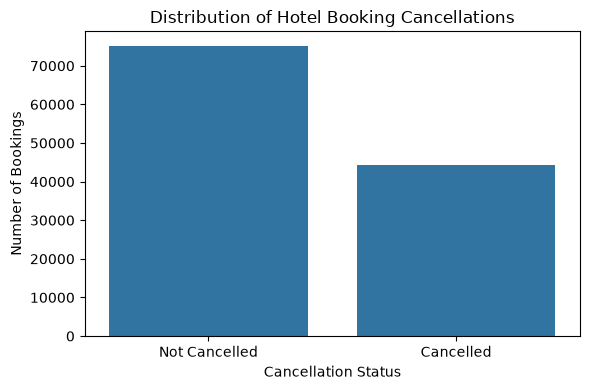

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="is_canceled"
)

plt.title("Distribution of Hotel Booking Cancellations")
plt.xlabel("Cancellation Status")
plt.ylabel("Number of Bookings")
plt.xticks([0, 1], ["Not Cancelled", "Cancelled"])

plt.tight_layout()

plt.savefig(
    "../../results/figures/target_cancellation_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Initial Data Quality Findings

- The dataset contains 119,390 records and 32 columns.
- The target variable is `is_canceled`.
- 75,166 bookings (62.96%) were not cancelled.
- 44,224 bookings (37.04%) were cancelled.
- The target classes are moderately distributed and do not show severe class imbalance.
- Missing values are present in `company`, `agent`, `country`, and `children`.
- `company` has a very large number of missing values.
- 31,994 duplicate rows were detected.
- Duplicate records will be investigated before removal because the dataset does not contain a unique booking identifier.

## Numerical Feature Analysis

In [7]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

df[numerical_columns].describe().T

Numerical Columns:
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [8]:
important_numerical = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "adr"
]

for column in important_numerical:
    print(f"\n--- {column} ---")
    print(df[column].describe())


--- lead_time ---
count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

--- stays_in_weekend_nights ---
count    119390.000000
mean          0.927599
std           0.998613
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          19.000000
Name: stays_in_weekend_nights, dtype: float64

--- stays_in_week_nights ---
count    119390.000000
mean          2.500302
std           1.908286
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          50.000000
Name: stays_in_week_nights, dtype: float64

--- adults ---
count    119390.000000
mean          1.856403
std           0.579261
min           0.000000
25%           2.000000
50%           2.000000
75%           2.000000
max          55.000000
Name: adults, dtype: float64

--- children --

## Numerical EDA Findings

- `lead_time` ranges from 0 to 737 days and appears strongly right-skewed.
- `stays_in_weekend_nights` has a maximum of 19 nights, while 75% of bookings have 2 or fewer weekend nights.
- `stays_in_week_nights` has a maximum of 50 nights, while 75% of bookings have 3 or fewer week nights.
- `adults` has a maximum value of 55, which is unusually high compared with the typical booking of 2 adults.
- `children` and `babies` both contain unusually high maximum values of 10.
- `previous_cancellations` reaches 26 even though most records contain 0 previous cancellations.
- `adr` contains a negative minimum value (-6.38) and an extreme maximum value (5400), so this variable requires further investigation.
- `agent` and `company` are identifier-like variables and should not be interpreted as continuous numerical measurements.
- Potential outliers will be investigated before deciding whether they should be removed, capped, transformed, or retained.

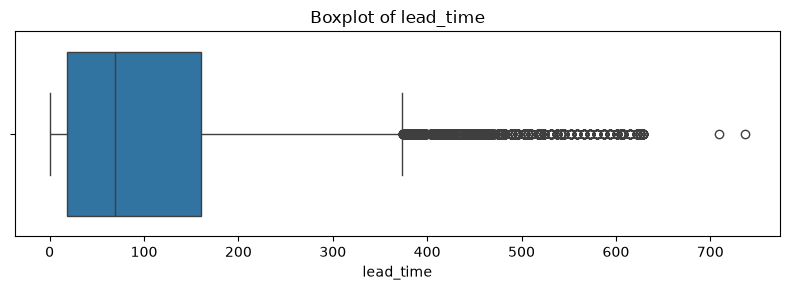

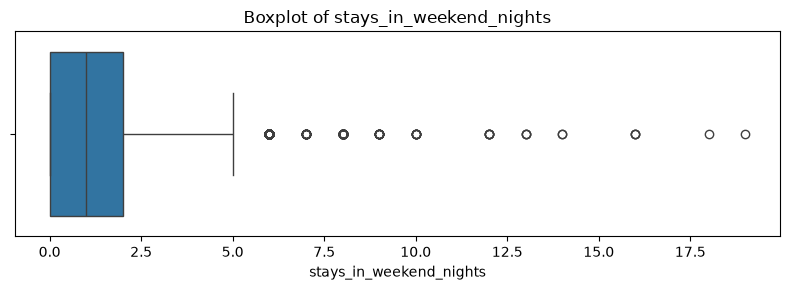

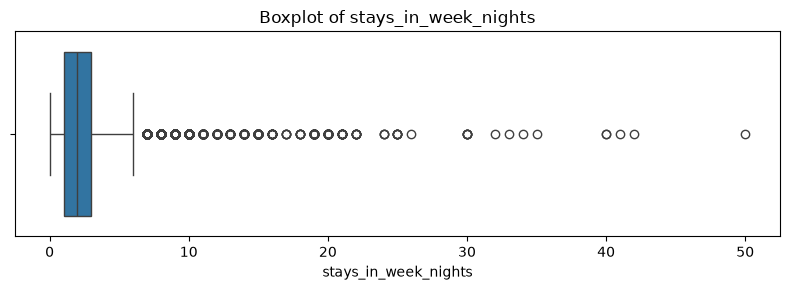

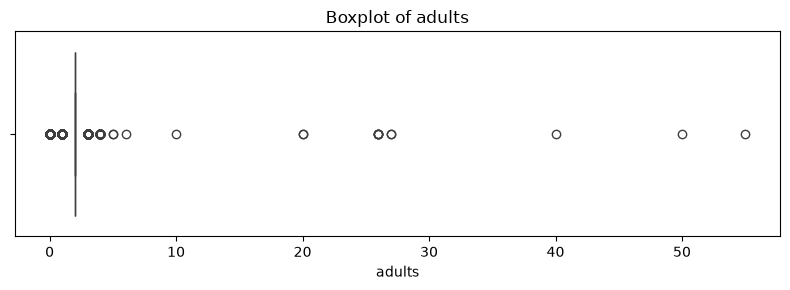

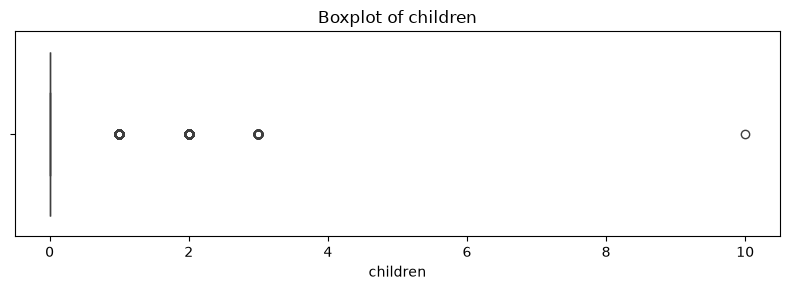

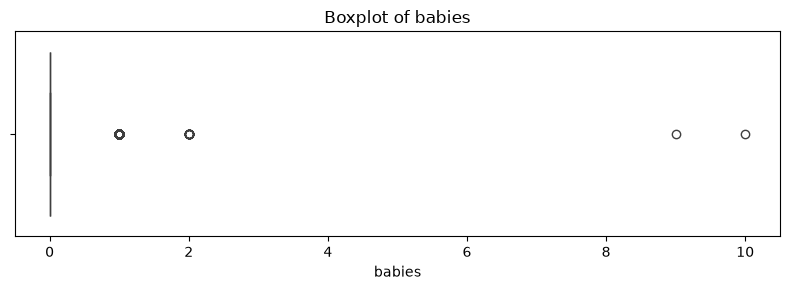

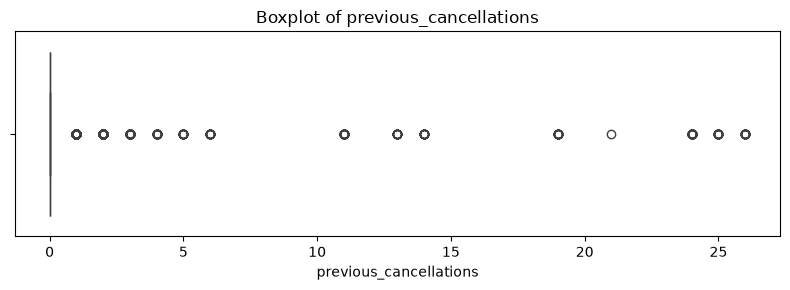

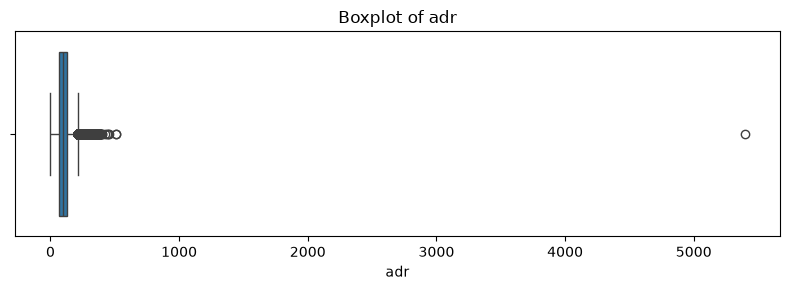

In [9]:
features_to_check = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "adr"
]

for column in features_to_check:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.tight_layout()
    plt.show()

In [10]:
print("Bookings with more than 10 adults:")
display(df[df["adults"] > 10][
    ["hotel", "adults", "children", "babies", "is_canceled"]
])

print("\nBookings with ADR below 0:")
display(df[df["adr"] < 0][
    ["hotel", "adr", "is_canceled"]
])

print("\nBookings with ADR above 1000:")
display(df[df["adr"] > 1000][
    ["hotel", "adr", "is_canceled"]
])

print("\nBookings with more than 5 babies:")
display(df[df["babies"] > 5][
    ["hotel", "adults", "children", "babies", "is_canceled"]
])

Bookings with more than 10 adults:


,hotel,adults,children,babies,is_canceled
1539,Resort Hotel,40,0.0,0,1
1587,Resort Hotel,26,0.0,0,1
1643,Resort Hotel,50,0.0,0,1
1752,Resort Hotel,26,0.0,0,1
1884,Resort Hotel,26,0.0,0,1
1917,Resort Hotel,27,0.0,0,1
1962,Resort Hotel,27,0.0,0,1
2003,Resort Hotel,26,0.0,0,1
2164,Resort Hotel,26,0.0,0,1
2173,Resort Hotel,55,0.0,0,1



Bookings with ADR below 0:


,hotel,adr,is_canceled
14969,Resort Hotel,-6.38,0



Bookings with ADR above 1000:


,hotel,adr,is_canceled
48515,City Hotel,5400.0,1



Bookings with more than 5 babies:


,hotel,adults,children,babies,is_canceled
46619,City Hotel,2,0.0,10,0
78656,City Hotel,1,0.0,9,0


In [11]:
columns_to_view = [
    "hotel",
    "adults",
    "children",
    "babies",
    "market_segment",
    "distribution_channel",
    "customer_type",
    "reserved_room_type",
    "lead_time",
    "adr",
    "is_canceled"
]

print("Bookings with more than 10 adults:")
display(df[df["adults"] > 10][columns_to_view])

print("\nBookings with more than 5 babies:")
display(df[df["babies"] > 5][columns_to_view])

print("\nBookings with unusual ADR:")
display(df[(df["adr"] < 0) | (df["adr"] > 1000)][columns_to_view])

Bookings with more than 10 adults:


,hotel,adults,children,babies,market_segment,distribution_channel,customer_type,reserved_room_type,lead_time,adr,is_canceled
1539,Resort Hotel,40,0.0,0,Direct,Direct,Group,A,304,0.0,1
1587,Resort Hotel,26,0.0,0,Offline TA/TO,TA/TO,Group,A,333,0.0,1
1643,Resort Hotel,50,0.0,0,Direct,Direct,Group,A,336,0.0,1
1752,Resort Hotel,26,0.0,0,Offline TA/TO,TA/TO,Group,A,340,0.0,1
1884,Resort Hotel,26,0.0,0,Offline TA/TO,TA/TO,Group,A,347,0.0,1
1917,Resort Hotel,27,0.0,0,Direct,Direct,Group,A,349,0.0,1
1962,Resort Hotel,27,0.0,0,Direct,Direct,Group,A,352,0.0,1
2003,Resort Hotel,26,0.0,0,Offline TA/TO,TA/TO,Group,A,354,0.0,1
2164,Resort Hotel,26,0.0,0,Offline TA/TO,TA/TO,Group,A,361,0.0,1
2173,Resort Hotel,55,0.0,0,Direct,Direct,Group,A,338,0.0,1



Bookings with more than 5 babies:


,hotel,adults,children,babies,market_segment,distribution_channel,customer_type,reserved_room_type,lead_time,adr,is_canceled
46619,City Hotel,2,0.0,10,Online TA,TA/TO,Transient,D,37,84.45,0
78656,City Hotel,1,0.0,9,Corporate,Corporate,Transient-Party,A,11,95.00,0



Bookings with unusual ADR:


,hotel,adults,children,babies,market_segment,distribution_channel,customer_type,reserved_room_type,lead_time,adr,is_canceled
14969,Resort Hotel,2,0.0,0,Groups,Direct,Transient-Party,A,195,-6.38,0
48515,City Hotel,2,0.0,0,Offline TA/TO,TA/TO,Transient,A,35,5400.00,1


In [12]:
print("Number of bookings with adults > 10:",
      (df["adults"] > 10).sum())

print("Number of bookings with babies > 5:",
      (df["babies"] > 5).sum())

print("Number of bookings with ADR < 0:",
      (df["adr"] < 0).sum())

print("Number of bookings with ADR > 1000:",
      (df["adr"] > 1000).sum())

Number of bookings with adults > 10: 12
Number of bookings with babies > 5: 2
Number of bookings with ADR < 0: 1
Number of bookings with ADR > 1000: 1


### Outlier Investigation Findings

- Twelve displayed bookings contain more than 10 adults, with values ranging up to 55.
- These records are classified as `Group` bookings, which provides a reasonable business explanation for the unusually high number of adults. Therefore, they should not be automatically treated as errors.
- Two bookings contain unusually high numbers of babies (9 and 10). These records are not obviously explained by group-booking information and will require further consideration during preprocessing.
- One booking contains a negative ADR value of -6.38, which is unusual for a hotel room rate.
- One booking contains an extremely high ADR value of 5400 compared with the dataset median of approximately 94.58.
- Extreme values were investigated using their surrounding booking information rather than being removed solely because they were statistical outliers.

In [13]:
total_guests = (
    df["adults"]
    + df["children"].fillna(0)
    + df["babies"]
)

total_nights = (
    df["stays_in_weekend_nights"]
    + df["stays_in_week_nights"]
)

print("Bookings with zero total guests:",
      (total_guests == 0).sum())

print("Bookings with zero total nights:",
      (total_nights == 0).sum())

Bookings with zero total guests: 180
Bookings with zero total nights: 715


In [14]:
print("Zero-guest bookings:")
display(
    df[total_guests == 0][
        [
            "hotel",
            "adults",
            "children",
            "babies",
            "customer_type",
            "is_canceled"
        ]
    ].head(20)
)

print("Zero-night bookings:")
display(
    df[total_nights == 0][
        [
            "hotel",
            "stays_in_weekend_nights",
            "stays_in_week_nights",
            "adults",
            "children",
            "babies",
            "is_canceled"
        ]
    ].head(20)
)

Zero-guest bookings:


,hotel,adults,children,babies,customer_type,is_canceled
2224,Resort Hotel,0,0.0,0,Transient-Party,0
2409,Resort Hotel,0,0.0,0,Transient,0
3181,Resort Hotel,0,0.0,0,Transient-Party,0
3684,Resort Hotel,0,0.0,0,Transient-Party,0
3708,Resort Hotel,0,0.0,0,Transient-Party,0
4127,Resort Hotel,0,0.0,0,Transient,1
9376,Resort Hotel,0,0.0,0,Group,1
31765,Resort Hotel,0,0.0,0,Transient,0
32029,Resort Hotel,0,0.0,0,Transient-Party,0
32827,Resort Hotel,0,0.0,0,Transient,0


Zero-night bookings:


,hotel,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_canceled
0,Resort Hotel,0,0,2,0.0,0,0
1,Resort Hotel,0,0,2,0.0,0,0
167,Resort Hotel,0,0,2,0.0,0,0
168,Resort Hotel,0,0,1,0.0,0,0
196,Resort Hotel,0,0,2,0.0,0,0
197,Resort Hotel,0,0,2,0.0,0,0
459,Resort Hotel,0,0,2,0.0,0,0
568,Resort Hotel,0,0,1,0.0,0,0
569,Resort Hotel,0,0,2,0.0,0,0
618,Resort Hotel,0,0,2,2.0,0,0


In [15]:
zero_guest_mask = (
    (df["adults"] == 0) &
    (df["children"] == 0) &
    (df["babies"] == 0)
)

print("Confirmed bookings with zero guests:",
      zero_guest_mask.sum())

print("Rows with adults = 0, babies = 0 and children missing:",
      (
          (df["adults"] == 0) &
          (df["children"].isna()) &
          (df["babies"] == 0)
      ).sum()
)

Confirmed bookings with zero guests: 180
Rows with adults = 0, babies = 0 and children missing: 0


In [16]:
print(
    df.loc[zero_guest_mask, "is_canceled"]
      .value_counts()
)

is_canceled
0    155
1     25
Name: count, dtype: int64


### Zero-Guest Booking Finding

- 180 bookings contain zero adults, zero children, and zero babies.
- None of these records are caused by missing values in the `children` column.
- 155 of the zero-guest bookings were not cancelled and 25 were cancelled.
- These records appear logically inconsistent with a normal hotel reservation and will be reviewed for removal during preprocessing.

In [17]:
hotel_cancellation = (
    df.groupby("hotel")["is_canceled"]
      .agg(["count", "mean"])
)

hotel_cancellation["cancellation_percentage"] = (
    hotel_cancellation["mean"] * 100
)

hotel_cancellation

,count,mean,cancellation_percentage
hotel,,,
City Hotel,79330,0.417270,41.726963
Resort Hotel,40060,0.277634,27.763355


In [18]:
lead_time_by_cancellation = (
    df.groupby("is_canceled")["lead_time"]
      .agg(["count", "mean", "median"])
)

lead_time_by_cancellation

,count,mean,median
is_canceled,,,
0,75166,79.984687,45.0
1,44224,144.848815,113.0


### Cancellation Relationship Findings

- City Hotel bookings had a cancellation rate of approximately 41.73%, compared with 27.76% for Resort Hotel bookings.
- This suggests that hotel type is associated with cancellation behaviour in this dataset.
- Cancelled bookings had a much higher average lead time (approximately 145 days) than non-cancelled bookings (approximately 80 days).
- The median lead time was 113 days for cancelled bookings and 45 days for non-cancelled bookings.
- This suggests that bookings made further in advance may have a higher cancellation tendency.
- These findings show associations only and do not prove that hotel type or lead time directly causes cancellation.

In [19]:
previous_cancel_analysis = (
    df.groupby("is_canceled")["previous_cancellations"]
      .agg(["count", "mean", "median", "max"])
)

previous_cancel_analysis

,count,mean,median,max
is_canceled,,,,
0,75166,0.015792,0.0,13
1,44224,0.208348,0.0,26


In [20]:
df["has_previous_cancellation"] = (
    df["previous_cancellations"] > 0
)

previous_cancel_rate = (
    df.groupby("has_previous_cancellation")["is_canceled"]
      .agg(["count", "mean"])
)

previous_cancel_rate["cancellation_percentage"] = (
    previous_cancel_rate["mean"] * 100
)

previous_cancel_rate

,count,mean,cancellation_percentage
has_previous_cancellation,,,
False,112906,0.339061,33.906081
True,6484,0.916410,91.640962


In [21]:
market_segment_analysis = (
    df.groupby("market_segment")["is_canceled"]
      .agg(["count", "mean"])
)

market_segment_analysis["cancellation_percentage"] = (
    market_segment_analysis["mean"] * 100
)

market_segment_analysis.sort_values(
    "cancellation_percentage",
    ascending=False
)

,count,mean,cancellation_percentage
market_segment,,,
Undefined,2,1.000000,100.000000
Groups,19811,0.610620,61.062036
Online TA,56477,0.367211,36.721143
Offline TA/TO,24219,0.343160,34.316033
Aviation,237,0.219409,21.940928
Corporate,5295,0.187347,18.734655
Direct,12606,0.153419,15.341901
Complementary,743,0.130552,13.055182


### Previous Cancellation and Market Segment Findings

- Customers with no previous cancellation history had a cancellation rate of approximately 33.91%.
- Customers with at least one previous cancellation had a much higher cancellation rate of approximately 91.64%.
- This indicates a strong association between previous cancellation history and the current booking outcome.

- Cancellation rates also varied by market segment.
- Group bookings had a relatively high cancellation rate of approximately 61.06%.
- Online travel agency bookings had a cancellation rate of approximately 36.72%.
- Offline travel agency/tour operator bookings had a cancellation rate of approximately 34.32%.
- Direct bookings had a lower cancellation rate of approximately 15.34%.
- The `Undefined` market segment showed 100% cancellation, but it contained only 2 records, so this percentage is not reliable for general interpretation.
- These findings represent associations in the dataset and do not prove causation.

In [22]:
repeated_guest_analysis = (
    df.groupby("is_repeated_guest")["is_canceled"]
      .agg(["count", "mean"])
)

repeated_guest_analysis["cancellation_percentage"] = (
    repeated_guest_analysis["mean"] * 100
)

repeated_guest_analysis

,count,mean,cancellation_percentage
is_repeated_guest,,,
0,115580,0.377851,37.785084
1,3810,0.144882,14.488189


In [23]:
customer_type_analysis = (
    df.groupby("customer_type")["is_canceled"]
      .agg(["count", "mean"])
)

customer_type_analysis["cancellation_percentage"] = (
    customer_type_analysis["mean"] * 100
)

customer_type_analysis.sort_values(
    "cancellation_percentage",
    ascending=False
)

,count,mean,cancellation_percentage
customer_type,,,
Transient,89613,0.407463,40.746320
Contract,4076,0.309617,30.961727
Transient-Party,25124,0.254299,25.429868
Group,577,0.102253,10.225303


### Repeated Guest and Customer Type Findings

- Non-repeated guests had a cancellation rate of approximately 37.79%.
- Repeated guests had a much lower cancellation rate of approximately 14.49%.
- This suggests that repeat-guest status is associated with lower cancellation behaviour in this dataset.

- Cancellation rates also differed across customer types.
- `Transient` customers had the highest cancellation rate at approximately 40.75%.
- `Contract` customers had a cancellation rate of approximately 30.96%.
- `Transient-Party` customers had a cancellation rate of approximately 25.43%.
- `Group` customers had the lowest cancellation rate at approximately 10.23%.
- The `Group` category contains only 577 records, so its percentage should be interpreted with some caution.
- These patterns represent associations and do not establish causation.

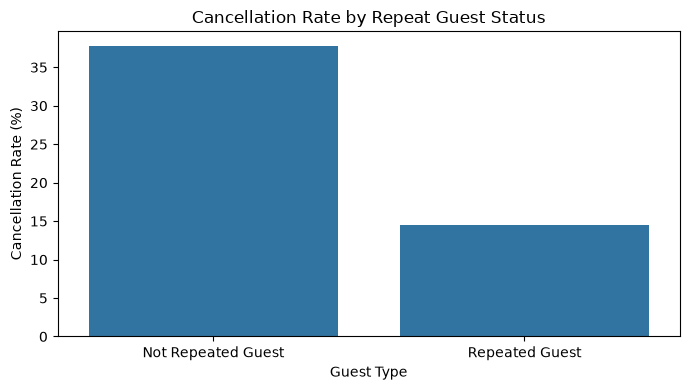

In [ ]:
repeat_plot = (
    repeated_guest_analysis
    .reset_index()
)

repeat_plot["guest_type"] = repeat_plot["is_repeated_guest"].map({
    0: "Not Repeated Guest",
    1: "Repeated Guest"
})

plt.figure(figsize=(7, 4))

sns.barplot(
    data=repeat_plot,
    x="guest_type",
    y="cancellation_percentage"
)

plt.title("Cancellation Rate by Repeat Guest Status")
plt.xlabel("Guest Type")
plt.ylabel("Cancellation Rate (%)")

plt.tight_layout()
plt.savefig(
    "../../results/figures/cancellation_by_repeated_guest.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

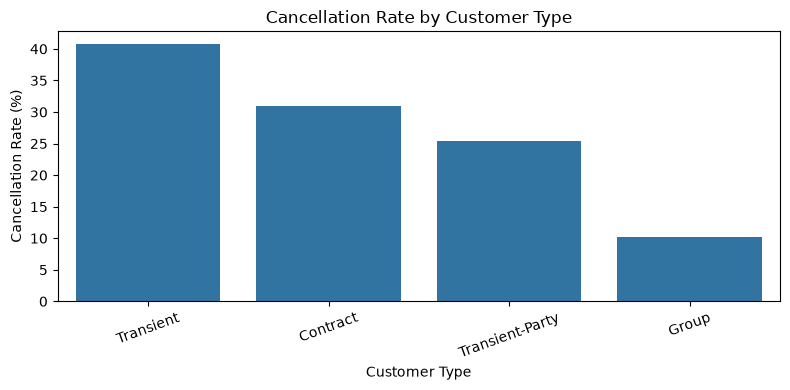

In [ ]:
customer_plot = (
    customer_type_analysis
    .reset_index()
    .sort_values("cancellation_percentage", ascending=False)
)

plt.figure(figsize=(8, 4))

sns.barplot(
    data=customer_plot,
    x="customer_type",
    y="cancellation_percentage"
)

plt.title("Cancellation Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Cancellation Rate (%)")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "../../results/figures/cancellation_by_customer_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

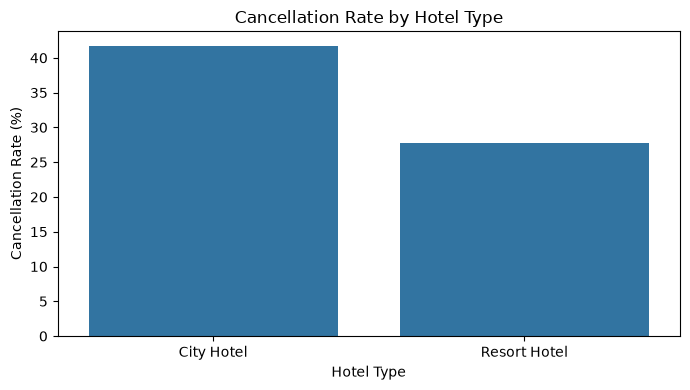

In [ ]:
hotel_plot = hotel_cancellation.reset_index()

plt.figure(figsize=(7, 4))

sns.barplot(
    data=hotel_plot,
    x="hotel",
    y="cancellation_percentage"
)

plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")

plt.tight_layout()

plt.savefig(
    "../../results/figures/cancellation_by_hotel_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

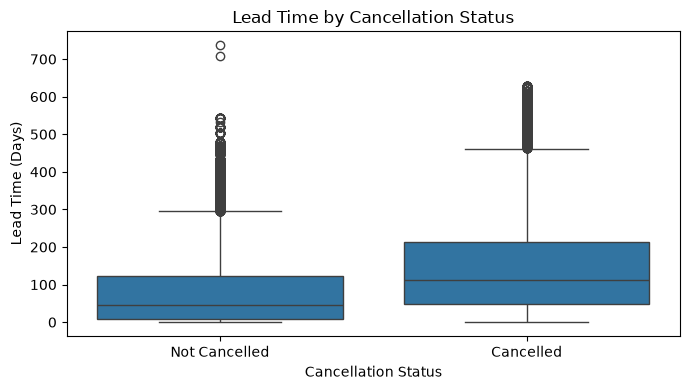

In [ ]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="lead_time"
)

plt.title("Lead Time by Cancellation Status")
plt.xlabel("Cancellation Status")
plt.ylabel("Lead Time (Days)")
plt.xticks([0, 1], ["Not Cancelled", "Cancelled"])

plt.tight_layout()

plt.savefig(
    "../../results/figures/lead_time_by_cancellation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

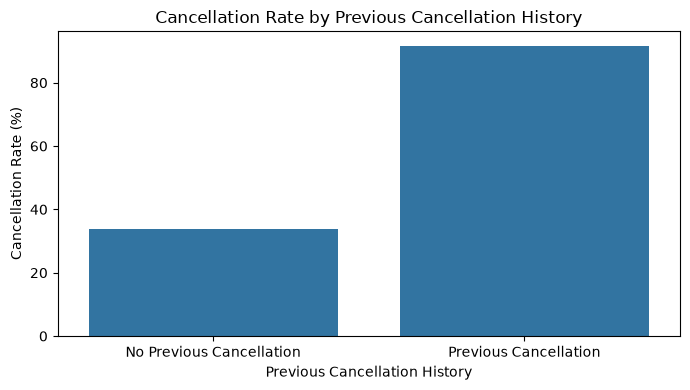

In [ ]:
previous_cancel_plot = (
    previous_cancel_rate
    .reset_index()
)

previous_cancel_plot["history"] = previous_cancel_plot[
    "has_previous_cancellation"
].map({
    False: "No Previous Cancellation",
    True: "Previous Cancellation"
})

plt.figure(figsize=(7, 4))

sns.barplot(
    data=previous_cancel_plot,
    x="history",
    y="cancellation_percentage"
)

plt.title("Cancellation Rate by Previous Cancellation History")
plt.xlabel("Previous Cancellation History")
plt.ylabel("Cancellation Rate (%)")

plt.tight_layout()

plt.savefig(
    "../../results/figures/cancellation_by_previous_history.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

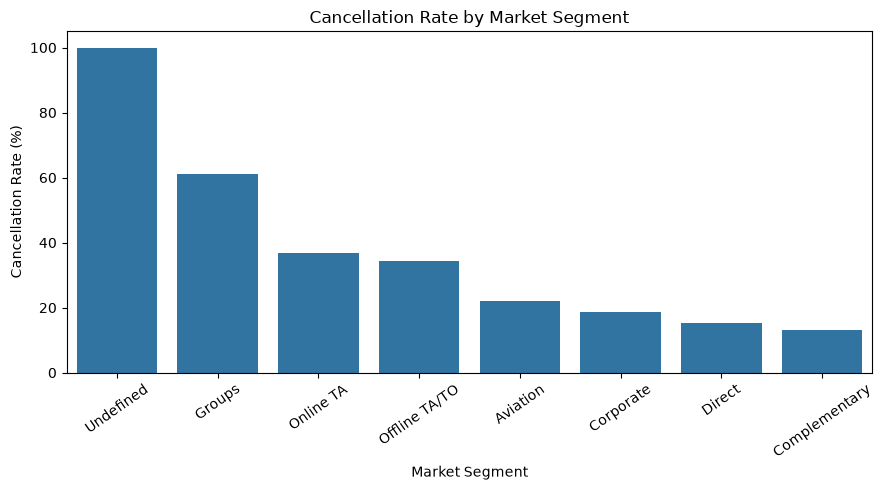

In [ ]:
market_plot = (
    market_segment_analysis
    .reset_index()
    .sort_values("cancellation_percentage", ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=market_plot,
    x="market_segment",
    y="cancellation_percentage"
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")

plt.xticks(rotation=35)
plt.tight_layout()

plt.savefig(
    "../../results/figures/cancellation_by_market_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Summary of Key EDA Findings

### Dataset Overview
- The dataset contains 119,390 hotel booking records and 32 columns.
- The target variable is `is_canceled`.
- 75,166 bookings (62.96%) were not cancelled.
- 44,224 bookings (37.04%) were cancelled.
- The target does not show severe class imbalance.

### Missing Values and Duplicates
- Missing values were identified in:
  - `company`: 112,593
  - `agent`: 16,340
  - `country`: 488
  - `children`: 4
- 31,994 duplicate rows were detected.
- Duplicate rows require further investigation because the dataset does not contain a unique booking identifier.

### Data Quality and Outliers
- 180 bookings contain zero adults, zero children, and zero babies.
- Some unusually large adult counts were found, but these were mainly `Group` bookings and may be legitimate.
- Two bookings contained unusually high numbers of babies (9 and 10).
- One ADR value was negative (-6.38).
- One ADR value was extremely high (5400).
- Extreme values were investigated before considering removal rather than being automatically treated as errors.

### Cancellation Patterns
- City Hotel cancellation rate: approximately 41.73%.
- Resort Hotel cancellation rate: approximately 27.76%.
- Cancelled bookings had a higher average lead time (~145 days) than non-cancelled bookings (~80 days).
- Customers with at least one previous cancellation had a cancellation rate of approximately 91.64%, compared with 33.91% for those without a previous cancellation.
- Group market-segment bookings had a relatively high cancellation rate of approximately 61.06%.
- Repeated guests had a substantially lower cancellation rate (~14.49%) than non-repeated guests (~37.79%).
- Transient customers had the highest cancellation rate among customer types at approximately 40.75%.

### Interpretation
The EDA suggests that hotel type, lead time, previous cancellation history, repeat-guest status, market segment, and customer type may be useful predictors of cancellation. These findings show associations within the dataset and do not establish causal relationships.

In [ ]:
hotel_cancellation.to_csv(
    "../../results/tables/cancellation_by_hotel_type.csv"
)

lead_time_by_cancellation.to_csv(
    "../../results/tables/lead_time_by_cancellation.csv"
)

previous_cancel_rate.to_csv(
    "../../results/tables/cancellation_by_previous_history.csv"
)

market_segment_analysis.to_csv(
    "../../results/tables/cancellation_by_market_segment.csv"
)

repeated_guest_analysis.to_csv(
    "../../results/tables/cancellation_by_repeated_guest.csv"
)

customer_type_analysis.to_csv(
    "../../results/tables/cancellation_by_customer_type.csv"
)

print("EDA tables saved successfully.")

EDA tables saved successfully.
